### Generates scatter plots to visualize solver failure points.

This script queries a benchmark database to identify interior-point method (IPM) iterations where the solver's residual norm exceeded the PCG tolerance. It then creates a grid of scatter plots, one for each solver, showing these failure points as a function of the problem size (number of edges).

In [220]:
import sqlite3
import polars as pl
import matplotlib.pyplot as plt
import argparse
import re
import numpy as np

In [221]:
def query_failure_points(db_path):
    conn = sqlite3.connect(f"file:{db_path}?mode=ro", uri=True)
    query = """
    WITH data AS (
        SELECT
            p.name AS problem_name,
            p.num_edges,
            r.solver_name,
            r.iters,
            sh.ipm_iter,
            sh.absolute_residual_norm,
            sh.relative_residual_norm,
            COALESCE(c.pcg_tol, 1e-6) AS pcg_tol
        FROM
            solver_history sh
        JOIN
            runs r ON sh.run_id = r.id
        JOIN
            problems p ON r.problem_id = p.id
        JOIN
            configs c ON r.config_id = c.id
    )
    SELECT *,
    relative_residual_norm > pcg_tol AS is_failure
    FROM data
    ORDER BY problem_name, solver_name, ipm_iter;
    """
    df = pl.read_database(query, conn)
    conn.close()
    print(f"Data loaded from database: {df}")
    return df


In [222]:
def plot_failure_points(db_path, problem_pattern=None, solver_pattern=None):
    df = query_failure_points(db_path)

    if df.is_empty():
        print("No failures found matching the criteria.")
        return

    if problem_pattern:
        df = df.filter(
            pl.col("problem_name").str.contains(problem_pattern, strict=False)
        )
    if solver_pattern:
        df = df.filter(pl.col("solver_name").str.contains(solver_pattern, strict=False))

    if df.is_empty():
        print(
            f"No data found after applying filters (problem_pattern='{problem_pattern}', solver_pattern='{solver_pattern}')."
        )
        return

    unique_solvers = df["solver_name"].unique().to_list()
    # Get unique problems and their num_edges for sorting
    problem_edges_df = df.group_by("problem_name").agg(pl.col("num_edges").first())
    sorted_problems = problem_edges_df.sort("num_edges")["problem_name"].to_list()
    unique_problems = sorted_problems # Use sorted problems

    # Create a numerical mapping for problem names for the x-axis
    problem_to_x_map = {problem: i for i, problem in enumerate(unique_problems)}
    x_ticks = list(problem_to_x_map.values())
    x_labels = list(problem_to_x_map.keys())

    colors = plt.get_cmap("Dark2", len(unique_solvers)) # Changed to Dark2 for darker, distinct colors
    solver_color_map = {
        solver: colors(i) for i, solver in enumerate(unique_solvers)
    }

    markers = ['x', '+', 'D', '^', 'v', '<', '>', 'p', 'h', 'o', 's', '*'] # Changed default to 'x' and '+'
    solver_marker_map = {
        solver: markers[i % len(markers)] for i, solver in enumerate(unique_solvers)
    }

    fig, ax = plt.subplots(figsize=(15, 8)) # Create a single figure and axis, wider for more problems

    # Calculate offsets for solvers within each problem group
    num_solvers = len(unique_solvers)
    offset_group_width = 0.3 # Total width for all solver points for one problem (smaller for tighter grouping)
    offsets = np.linspace(-0.4 + offset_group_width / 2, 0.4 - offset_group_width / 2, num_solvers)
    solver_offset_map = {solver: offsets[i] for i, solver in enumerate(unique_solvers)}

    # Store handles and labels to create a single legend at the end
    all_handles = []
    all_labels = []

    for problem_idx, problem in enumerate(unique_problems):
        problem_x_pos = problem_to_x_map[problem]
        problem_df = df.filter(pl.col("problem_name") == problem)

        # Shade alternating problem regions for visual grouping
        if problem_idx % 2 == 0:
            ax.axvspan(problem_x_pos - 0.5, problem_x_pos + 0.5, facecolor='lightgray', alpha=0.2)
        
        # Add darker gray boundary between regions
        ax.axvline(problem_x_pos - 0.5, color='dimgray', linestyle='-', linewidth=0.5)

        for solver in unique_solvers:
            problem_solver_df = problem_df.filter(pl.col("solver_name") == solver)
            # Apply offset to the problem's x-position
            x_positions_with_offset = problem_x_pos + solver_offset_map[solver]
            problem_solver_failure_df = problem_solver_df.filter(pl.col("is_failure") == True)
            if not problem_solver_failure_df.is_empty():
                scatter_handle = ax.scatter(
                    [x_positions_with_offset] * len(problem_solver_failure_df), # Repeat x-pos for all points of this solver/problem
                    problem_solver_failure_df["ipm_iter"],
                    color=solver_color_map[solver], # Color by solver
                    marker=solver_marker_map[solver], # Marker by solver
                    alpha=1.0, # Non-transparent
                    s=10, # Smaller dot size
                    label=solver # Always add label, will filter unique later
                )
                all_handles.append(scatter_handle)
                all_labels.append(solver)

            # Add horizontal red line at 'iters' value
            # Assuming 'iters' is a single value for each problem-solver combination in the filtered df
            if not problem_solver_df["iters"].is_empty():
                iters_value = problem_solver_df["iters"].unique().to_list()[0]
                ax.hlines(y=iters_value, xmin=x_positions_with_offset - offset_group_width / (2 * num_solvers), 
                            xmax=x_positions_with_offset + offset_group_width / (2 * num_solvers), 
                            color='red', linestyle='-', linewidth=1.5)

    # Add a final boundary line after the last problem
    ax.axvline(len(unique_problems) - 0.5, color='dimgray', linestyle='-', linewidth=0.5)

    # Set x-axis ticks and labels to problem names
    ax.set_xticks(x_ticks)
    ax.set_xticklabels(x_labels, rotation=45, ha="right")
    ax.set_xlabel("Problem Name", fontsize=12)
    ax.set_ylabel("IPM Iteration", fontsize=12)
    ax.set_title("IPM Iterations at which Residual Norm > pcg_tol", fontsize=14)
    ax.grid(True, which="both", ls="--")
    ax.tick_params(axis="both", which="major", labelsize=10)
    ax.tick_params(axis="both", which="minor", labelsize=8)

    # Create a single legend for solvers from collected handles/labels
    unique_legend_handles = []
    unique_legend_labels = []
    for h, l in zip(all_handles, all_labels):
        if l not in unique_legend_labels:
            unique_legend_labels.append(l)
            unique_legend_handles.append(h)

    ax.legend(unique_legend_handles, unique_legend_labels, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0., fontsize=8)

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
    plt.show()


Data loaded from database: shape: (4_665, 9)
┌────────────┬───────────┬────────────┬───────┬───┬────────────┬───────────┬───────────┬───────────┐
│ problem_na ┆ num_edges ┆ solver_nam ┆ iters ┆ … ┆ absolute_r ┆ relative_ ┆ pcg_tol   ┆ is_failur │
│ me         ┆ ---       ┆ e          ┆ ---   ┆   ┆ esidual_no ┆ residual_ ┆ ---       ┆ e         │
│ ---        ┆ i64       ┆ ---        ┆ i64   ┆   ┆ rm         ┆ norm      ┆ f64       ┆ ---       │
│ str        ┆           ┆ str        ┆       ┆   ┆ ---        ┆ ---       ┆           ┆ i64       │
│            ┆           ┆            ┆       ┆   ┆ f64        ┆ f64       ┆           ┆           │
╞════════════╪═══════════╪════════════╪═══════╪═══╪════════════╪═══════════╪═══════════╪═══════════╡
│ grid_h5_w1 ┆ 190       ┆ tulip_appr ┆ 5     ┆ … ┆ 6.5123e-8  ┆ 1.4220e-8 ┆ 5.0000e-8 ┆ 0         │
│ 0          ┆           ┆ oxchol     ┆       ┆   ┆            ┆           ┆           ┆           │
│ grid_h5_w1 ┆ 190       ┆ tulip_appr ┆ 5     

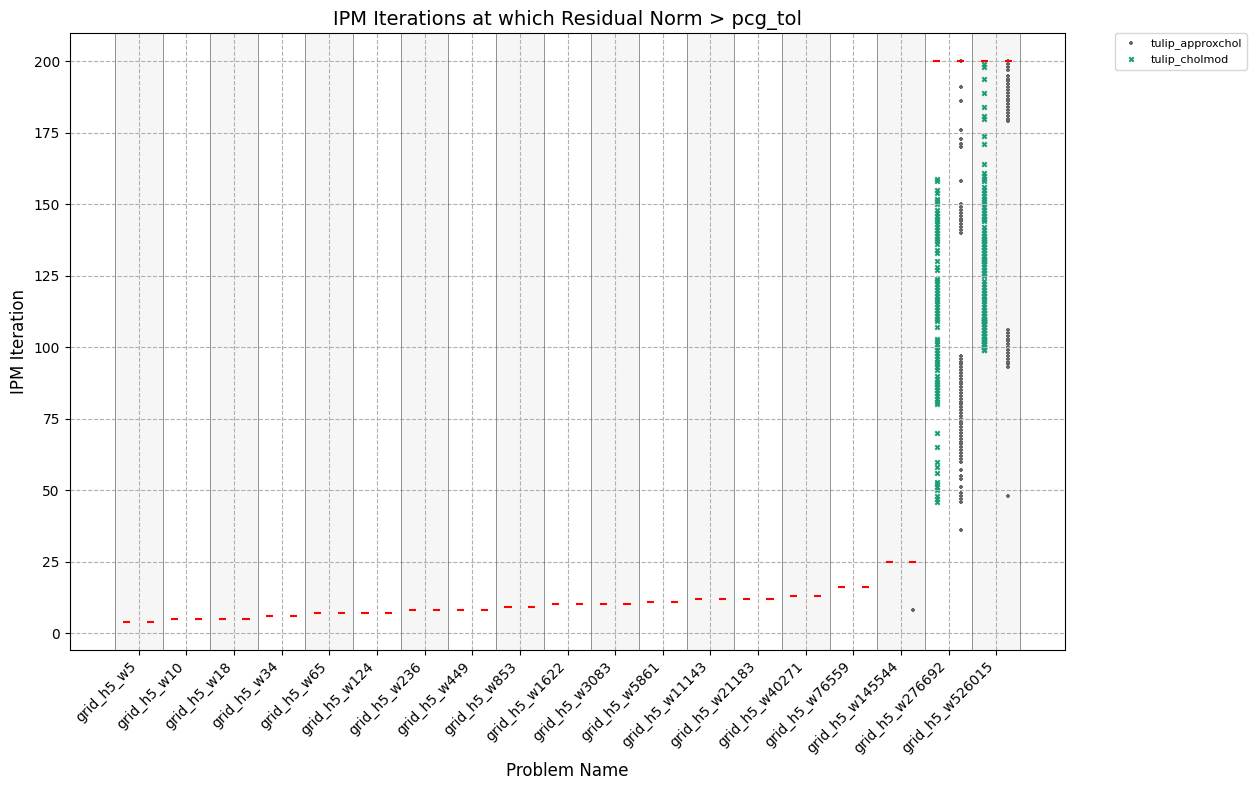

In [223]:
plot_failure_points("../unifwidegrid.db") # Assuming a default db file for demonstration
